<a href="https://colab.research.google.com/github/emilchafigoulline/Data-Science/blob/main/Unit7/Unit7ExercisesSF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fitting Curves: Concepts

What you'll do:

- Answer questions about what a GP is, and its relationship to GLMs and splines.
- Practice applying each of: polynomial modeling, b splines, and GPs
- You'll get a chance to read about and try to comprehend a more standard implementation of a GP.

Have fun!

In [1]:
!pip install git+https://github.com/pydata/xarray.git
!pip install bambi
!pip install preliz

  Cloning https://github.com/pydata/xarray.git to /tmp/pip-req-build-3q8dlba8
  Running command git clone --filter=blob:none --quiet https://github.com/pydata/xarray.git /tmp/pip-req-build-3q8dlba8
  Resolved https://github.com/pydata/xarray.git to commit c9ac506d723485adc7e75934739b3093227cce08
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached bambi-0.17.2-py3-none-any.whl.metadata (8.9 kB)
  Using cached arviz_plots-0.8.0-py3-none-any.whl.metadata (2.8 kB)
  Using cached formulae-0.6.2-py3-none-any.whl.metadata (4.0 kB)
  Using cached sparse-0.17.0-py2.py3-none-any.whl.metadata (5.3 kB)
  Using cached arviz_base-0.8.2-py3-none-any.whl.metadata (3.4 kB)
  Using cached arviz_stats-0.8.0-py3-none-any.whl.metadata (2.9 kB)
Using cached bambi-0.17.2-py3-none-any.whl (109 kB)
Using cached arviz_plots-0.8.0-py3-none-any.whl (218 kB)
Using cached formulae-0.6.2-py3-none-any.whl (54 kB)
Using c

In [2]:
import numpy as np
import pandas as pd
import arviz as az
import matplotlib.pyplot as plt
import xarray as xr
import bambi as bmb
import pymc as pm

**Task1**:

Why would you ever want to include a polynomial element in a model you built? What's the benefit of using polynomials to model?

Polynomials are better able to fit data closely as opposed to other model elements. This leads to a model better able to accurately fit our data.

**Task2**:

Why would you ever NOT want to include a polynomial element in a model you built?

However, if we include a polynomial element with too many orders, it can lead to overfitting to the data, which prevents the model from accurately predicting changes in the data from what is predicted.

**Task3**:

What's the point of using b splines?

The purpose of using b-splines is to compromise the flexibility of polynomial methods while still maintaining the ability to adapt to real world data that doesn't fit within a single polynomial trend easily.

**Task4**:

Describe what a Gaussian Process is, in your own words. *Don't worry about being correct, just try to explain it to yourself*. I will not grade this question for accuracy.

A Gaussian process is a way to deterine the number of knots needed in a model. This is done by placing each data point in a knot, relating them together instead of trying to place them into a model immediately, which leads to less overfitted results?

**Task5**:

Fit three models to the howell data (from Unit5ExercisesSF): polynomial, b splines, and Gaussian Process.

Plot the posterior predictive check on a scatter plot, as is standard/required.

Hint: Distributional models (variable variance) work better on the howell data.


In [3]:
howell = pd.read_csv('https://raw.githubusercontent.com/thedarredondo/data-science-fundamentals/main/Data/howell.csv')
howell

,height,weight,age,male
0,151.765,47.825606,63.0,1
1,139.700,36.485807,63.0,0
2,136.525,31.864838,65.0,0
3,156.845,53.041914,41.0,1
4,145.415,41.276872,51.0,0
...,...,...,...,...
539,145.415,31.127751,17.0,1
540,162.560,52.163080,31.0,1
541,156.210,54.062497,21.0,0
542,71.120,8.051258,0.0,1


In [ ]:
model_poly_7_t = bmb.Model("height ~ poly(weight, degree=3)", howell, family="negativebinomial")
idata_poly_7_t = model_poly_7_t.fit()

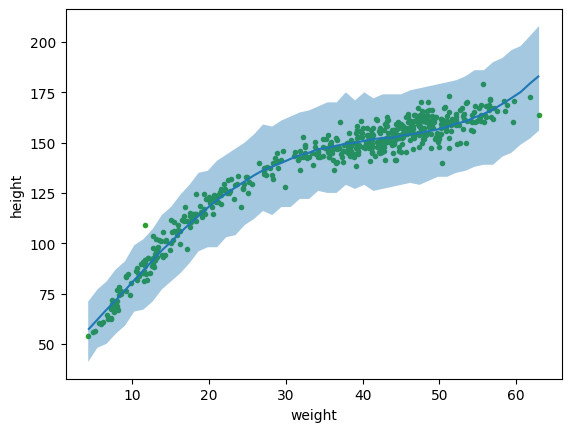

In [10]:
#plot of posterior predictive dist
bmb.interpret.plot_predictions(model_poly_7_t, idata_poly_7_t, "weight", pps=True)
#raw data
plt.plot(howell.weight, howell.height, "C2.", zorder=-3)

In [ ]:
num_knots = 4
knots = np.linspace(0, 23, num_knots+2)[1:-1]
model_spline = bmb.Model("height ~ bs(weight, degree=3, knots=knots)", howell, family="negativebinomial")
idata_spline = model_spline.fit()

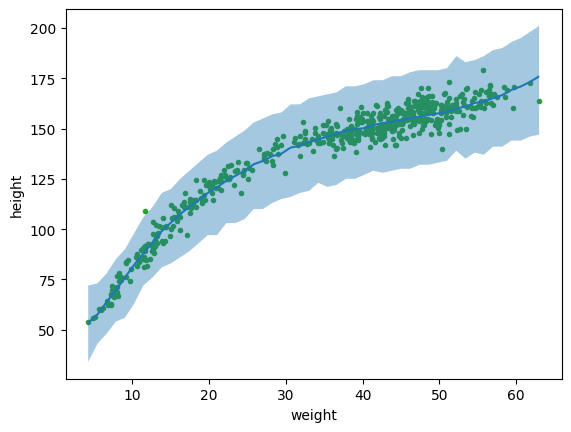

In [12]:

bmb.interpret.plot_predictions(model_spline, idata_spline, "weight", pps= True)
plt.plot(howell.weight, howell.height, "C2.", zorder=-3)

In [ ]:
Didn't understand the GP well enough to create the model right now.

**Task6**:

Read the article on the pymc website about GP implementation on the Mauna Loa CO$_{2}$ data combined with CO$_{2}$ ice core data from the south pole.
[Link here.](https://www.pymc.io/projects/examples/en/latest/gaussian_processes/GP-MaunaLoa2.html)

Write down one thing you learned about GPs from reading the article.

Note: You probably won't understand much in this article--I had to read it about five times before I figured out what was going on. The points of this task are to: hammer home that good GP implementations are extremely technical, and increasure your exposure to the kinds of problems traditional GPs are good at solving.

Gaussian processes can use multiple kernels to model different aspect of the data. For example, one kernel can represent the squiggly, more random part, while another represents the long term upward trend in CO2

**Task7**:

Describe your favorite graph from the article in the previous task with as much technical detail as you can muster.

Explain why its your favorite.

My favorite graph is the one that shows the CO2 trend line, where starting at x = 40 the line drastically changes. It starts changing much more drastically than before, with sharp cutoffs instead of smmooth changes. I like this because it shows a sharp contrast, which can be attributed to real events in the world, making the model applicable to reality.